# NTK visualization
This notebook aims to compare the **empirical** Neural Tangent Kernel of different architectures. 

Architectures analysed:
- Base Kernel (just the MLP)
- PINN
- Fourier Features
- SIRENs

We'll consider functions which maps to an unidimensional space to ease the visualisation

## Setup

In [ ]:
from pathlib import Path
import sys

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path().resolve()
while not (ROOT / "src").is_dir():
    if ROOT == ROOT.parent:
        raise RuntimeError(f"Cannot find project root from {Path().resolve()}")
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))
print(f"ROOT = {ROOT}")

from src.PINNs import PINN, PINNConfig
from src.spectral_analysis import compute_ntk

sns.set_theme(style="whitegrid")
torch.manual_seed(42)
np.random.seed(42)

FIGURES_DIR = Path().resolve() / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
print(f"Figures -> {FIGURES_DIR}")

In [ ]:
from argparse import Namespace

opt = Namespace()

# ODE (used for PINN NTK section)
opt.alpha  = 1.0
opt.freqs  = [1.0, 3.0, 5.0, 10.0]
opt.amps   = [1.0, 1.0, 1.0, 1.0]
opt.phases = [0.0, 0.0, 0.0, 0.0]
opt.y0     = [0.0]
opt.T      = 2.0

# Evaluation grid
opt.N_POINTS = 200

# Common architecture size
WIDTH = 128
DEPTH = 4

# Fourier embedding frequencies (cover the ODE forcing + harmonics)
FOURIER_FREQS = [1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 15.0, 20.0]

# SIREN frequency scaling (Sitzmann et al. 2020)
SIREN_OMEGA = 30.0

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")

In [ ]:
class ForcedFirstOrderODE:
    """
    z' = -alpha*z + sum_k A_k sin(2*pi*f_k*t + phi_k)
    """

    def __init__(self, alpha, freqs, amps, phases):
        self.alpha  = alpha
        self.freqs  = list(freqs)
        self.amps   = list(amps)
        self.phases = list(phases)

    def _forcing(self, t, sin_fn):
        return sum(
            A * sin_fn(2 * np.pi * f * t + ph)
            for f, A, ph in zip(self.freqs, self.amps, self.phases)
        )

    def rhs_np(self, t, z):
        return [-self.alpha * z[0] + self._forcing(t, np.sin)]

    def rhs_torch(self, t, z):
        return -self.alpha * z + self._forcing(t, torch.sin)


Picard (20 iterations)...


In [ ]:
ode    = ForcedFirstOrderODE(opt.alpha, opt.freqs, opt.amps, opt.phases)
t_eval = np.linspace(0, opt.T, opt.N_POINTS).astype(np.float32)

## Architecture Definitions

In [ ]:
class SirenLayer(nn.Linear):
    """Single SIREN hidden layer: sin(ω₀ · Wx + b) with He-style init."""

    def __init__(self, in_f: int, out_f: int, omega_0: float = 30.0, is_first: bool = False):
        super().__init__(in_f, out_f)
        with torch.no_grad():
            if is_first:
                self.weight.uniform_(-1.0 / in_f, 1.0 / in_f)
            else:
                self.weight.uniform_(
                    -np.sqrt(6.0 / in_f) / omega_0,
                     np.sqrt(6.0 / in_f) / omega_0,
                )
        self.omega_0 = omega_0

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.sin(self.omega_0 * super().forward(x))


class SIREN(nn.Module):
    """SINusoidal REpresentation Network (Sitzmann et al. 2020).
    Final layer is linear (no sine) so the output range is unconstrained.
    """

    def __init__(self, n_in: int = 1, n_out: int = 1,
                 width: int = 128, depth: int = 4, omega_0: float = 30.0):
        super().__init__()
        layers = [SirenLayer(n_in, width, omega_0=omega_0, is_first=True)]
        for _ in range(depth - 2):
            layers.append(SirenLayer(width, width, omega_0=omega_0))
        layers.append(nn.Linear(width, n_out))
        self.net = nn.Sequential(*layers)

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        return self.net(t)


# --- Instantiate all architectures at random initialisation ---
mlp     = PINN(PINNConfig(n_vars=1, width=WIDTH, depth=DEPTH)).to(DEVICE)
fourier = PINN(PINNConfig(n_vars=1, width=WIDTH, depth=DEPTH, fourier_freqs=FOURIER_FREQS)).to(DEVICE)
siren   = SIREN(width=WIDTH, depth=DEPTH, omega_0=SIREN_OMEGA).to(DEVICE)

MODELS = {
    "MLP (Tanh)":   mlp,
    "Fourier MLP":  fourier,
    "SIREN":        siren,
}

print(f"{'Architecture':<20} {'Params':>10}")
print("-" * 32)
for name, m in MODELS.items():
    P = sum(p.numel() for p in m.parameters())
    print(f"{name:<20} {P:>10,}")

In [ ]:
print("Computing NTK matrices at random initialisation...")
print(f"  Grid: {len(t_eval)} points  |  arch width={WIDTH}, depth={DEPTH}\n")

ntk_matrices    = {}
ntk_eigenvalues = {}
ntk_eigenvectors = {}

for name, model in MODELS.items():
    print(f"  {name}...", end=" ", flush=True)
    K = compute_ntk(model, t_eval, device=DEVICE)
    vals, vecs = np.linalg.eigh(K)
    ntk_matrices[name]     = K
    ntk_eigenvalues[name]  = vals[::-1].copy()
    ntk_eigenvectors[name] = vecs[:, ::-1].copy()
    eff_rank = int((vals.sum() ** 2) / (vals ** 2).sum())   # participation ratio
    print(f"λ_max={vals[-1]:.2e}  λ_min={vals[vals > 0].min():.2e}  eff_rank≈{eff_rank}")

# PINN NTK: same MLP backbone but Jacobian is ∂R/∂θ instead of ∂f/∂θ
print(f"  PINN NTK (K_ff)...", end=" ", flush=True)
K_pinn = mlp.ntk(t_eval, ode.rhs_torch, device=DEVICE)
vals_p, vecs_p = np.linalg.eigh(K_pinn)
ntk_matrices["PINN NTK"]     = K_pinn
ntk_eigenvalues["PINN NTK"]  = vals_p[::-1].copy()
ntk_eigenvectors["PINN NTK"] = vecs_p[:, ::-1].copy()
eff_rank_p = int((vals_p.sum() ** 2) / (vals_p ** 2).sum())
print(f"λ_max={vals_p[-1]:.2e}  λ_min={vals_p[vals_p > 0].min():.2e}  eff_rank≈{eff_rank_p}")

ARCH_NAMES = list(ntk_matrices.keys())
PALETTE    = dict(zip(ARCH_NAMES, sns.color_palette("tab10", len(ARCH_NAMES))))

## Visualizations

### NTK Heatmaps

`K[i, j]` measures how correlated the gradient directions are at inputs `t_i` and `t_j`.
A kernel concentrated along the diagonal indicates localised representations; off-diagonal mass
indicates that learning at one point affects many others.
Each matrix is normalised by its maximum value for comparability.

In [ ]:
N = len(ARCH_NAMES)
fig, axes = plt.subplots(1, N, figsize=(4.5 * N, 4.2))
fig.suptitle("NTK Heatmaps (normalised)", fontsize=13)

for ax, name in zip(axes, ARCH_NAMES):
    K     = ntk_matrices[name]
    K_vis = K / K.max()
    im = ax.imshow(
        K_vis, cmap="viridis", aspect="auto",
        extent=[t_eval[0], t_eval[-1], t_eval[-1], t_eval[0]],
        vmin=0, vmax=1,
    )
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("t")
    ax.set_ylabel("t'")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "ntk_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

### Kernel slice  k(t, t★)

Fixing one argument at a centre point `t★` and varying the other gives a 1-D cross-section of
the kernel. Its width and shape reveal how far the influence of a single training point spreads:
a narrow peak → localised, independent representations; a broad or oscillatory profile →
long-range correlations across the input domain.
Slices are normalised by `k(t★, t★)` so they all start at 1 and are directly comparable.

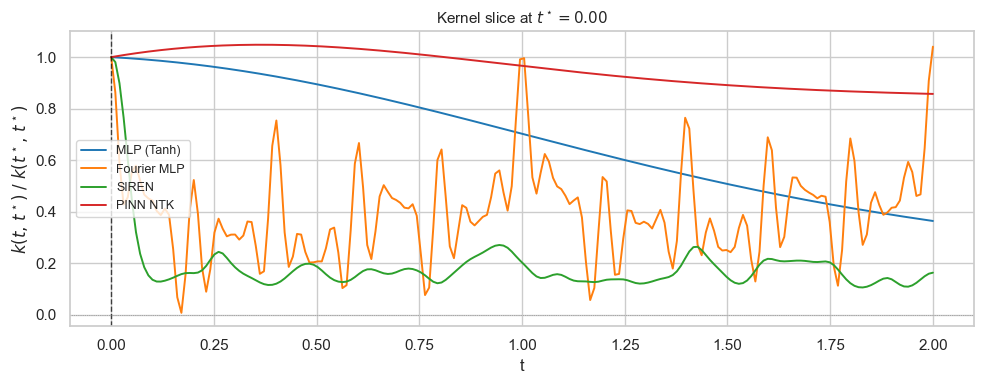

In [29]:
T_STAR = 0
center_idx   = np.argmin(np.abs(t_eval - T_STAR))
t_star_actual = float(t_eval[center_idx])

fig, ax = plt.subplots(figsize=(10, 4))

for name in ARCH_NAMES:
    K     = ntk_matrices[name]
    slice_ = K[:, center_idx] / K[center_idx, center_idx]   # normalise so k(t★, t★) = 1
    ax.plot(t_eval, slice_, label=name, color=PALETTE[name], linewidth=1.4)

ax.axvline(t_star_actual, color="black", linestyle="--", linewidth=1.0, alpha=0.7)
ax.axhline(0, color="gray", linewidth=0.5, linestyle=":")
ax.set_xlabel("t")
ax.set_ylabel(r"$k(t,\, t^\star)\;/\; k(t^\star,\, t^\star)$")
ax.set_title(f"Kernel slice at $t^\\star = {t_star_actual:.2f}$", fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "ntk_kernel_slice.png", dpi=150, bbox_inches="tight")
plt.show()

### Eigenvalue Spectra

Under gradient-flow, the projection of the error onto the `k`-th NTK eigenvector decays at rate
`exp(-η λ_k t)`. Architectures with a flatter spectrum (slower eigenvalue decay) converge more
uniformly across frequencies — less spectral bias.

The **cumulative trace fraction** shows what share of the total learning speed is concentrated
in the top-k eigenmodes (effective rank).

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("NTK Eigenvalue Spectra", fontsize=13)

idx = np.arange(1, len(t_eval) + 1)

ax = axes[0]
for name in ARCH_NAMES:
    vals = ntk_eigenvalues[name]
    ax.semilogy(idx, vals, label=name, color=PALETTE[name], linewidth=1.4)
ax.set_xlabel("Eigenvalue index (descending)")
ax.set_ylabel("Eigenvalue  (log scale)")
ax.set_title("Spectrum")
ax.legend(fontsize=9)

ax = axes[1]
for name in ARCH_NAMES:
    vals = ntk_eigenvalues[name]
    cum  = np.cumsum(vals) / vals.sum()
    ax.plot(idx, cum, label=name, color=PALETTE[name], linewidth=1.4)
ax.axhline(0.95, color="gray", linestyle="--", linewidth=0.9, label="95 % trace")
ax.set_xlabel("Eigenvalue index (descending)")
ax.set_ylabel("Cumulative fraction of trace")
ax.set_title("Spectral energy distribution  (effective rank)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "ntk_spectra.png", dpi=150, bbox_inches="tight")
plt.show()

### Leading Eigenvectors

The top eigenvectors are the spatial patterns learned first under gradient flow.
A vanilla MLP (spectral bias) will show smooth low-frequency patterns in v₁, v₂, ...
Fourier and SIREN architectures should show higher-frequency content early in the spectrum.

In [ ]:
N_VEC = 6
sample_rate = opt.N_POINTS / opt.T

fig, axes = plt.subplots(
    len(ARCH_NAMES), N_VEC,
    figsize=(2.8 * N_VEC, 2.4 * len(ARCH_NAMES)),
    sharex=True,
)
fig.suptitle(f"Top-{N_VEC} NTK Eigenvectors", fontsize=13)

for row, name in enumerate(ARCH_NAMES):
    vecs = ntk_eigenvectors[name]
    vals = ntk_eigenvalues[name]
    col_color = PALETTE[name]

    for col in range(N_VEC):
        ax = axes[row, col]
        v = vecs[:, col]
        v = v * np.sign(v[np.argmax(np.abs(v))])   # fix sign convention
        ax.plot(t_eval, v, linewidth=1.1, color=col_color, alpha=0.9)
        ax.axhline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.4)
        ax.set_ylim(-0.16, 0.16)

        if row == 0:
            ax.set_title(f"v{col+1}\nλ={vals[col]:.1e}", fontsize=8)
        if col == 0:
            ax.set_ylabel(name, fontsize=9)
        if row == len(ARCH_NAMES) - 1:
            ax.set_xlabel("t", fontsize=8)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "ntk_eigenvectors.png", dpi=150, bbox_inches="tight")
plt.show()

### Dominant frequency of each eigenvector

Reading the NTK eigenvectors in the Fourier domain reveals the frequency content the network
preferentially learns at each rank. Spectral bias predicts that lower-rank (larger λ) eigenvectors
carry lower frequencies for a vanilla MLP.

In [ ]:
def dominant_freq(vec, sample_rate):
    """Return the frequency [Hz] carrying the most power in vec (skip DC)."""
    freqs = np.fft.rfftfreq(len(vec), d=1.0 / sample_rate)
    spec  = np.abs(np.fft.rfft(vec))
    spec[0] = 0.0          # zero out DC
    return freqs[np.argmax(spec)]

fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle("Dominant Frequency per NTK Eigenvector", fontsize=12)

for name in ARCH_NAMES:
    vecs = ntk_eigenvectors[name]
    dom  = np.array([dominant_freq(vecs[:, k], sample_rate) for k in range(len(t_eval))])
    ax.scatter(
        np.arange(1, len(t_eval) + 1), dom,
        s=4, alpha=0.5, label=name, color=PALETTE[name],
    )

for f in opt.freqs:
    ax.axhline(f, color="gray", linestyle=":", linewidth=0.8, alpha=0.6)

ax.set_xlabel("Eigenvalue rank (1 = largest)")
ax.set_ylabel("Dominant frequency [Hz]")
ax.set_xlim(0, 60)
ax.set_ylim(0, max(opt.freqs) * 1.6)
ax.legend(fontsize=9, markerscale=3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "ntk_dominant_freq.png", dpi=150, bbox_inches="tight")
plt.show()

## Physics-Informed NTK vs Base NTK

The **PINN NTK** (`K_ff`) replaces the Jacobian `∂f/∂θ` with the residual Jacobian
`∂R/∂θ = ∂(ẑ' − F)/∂θ`. This incorporates the differential operator into the kernel, so
the eigenvalue structure now reflects how fast each spatial mode of the *ODE residual* converges,
rather than how fast the function values converge.

In [ ]:
K_base  = ntk_matrices["MLP (Tanh)"]
K_pinn  = ntk_matrices["PINN NTK"]
vals_b  = ntk_eigenvalues["MLP (Tanh)"]
vals_p  = ntk_eigenvalues["PINN NTK"]
vecs_b  = ntk_eigenvectors["MLP (Tanh)"]
vecs_p  = ntk_eigenvectors["PINN NTK"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Base NTK vs PINN NTK  (same MLP backbone, at initialisation)", fontsize=13)

# --- Row 0: heatmaps + spectrum ---
for ax, K, title in [
    (axes[0, 0], K_base / K_base.max(), "Base NTK  ∂f/∂θ"),
    (axes[0, 1], K_pinn / K_pinn.max(), "PINN NTK  ∂R/∂θ  (K_ff)"),
]:
    im = ax.imshow(
        K, cmap="viridis", aspect="auto",
        extent=[t_eval[0], t_eval[-1], t_eval[-1], t_eval[0]],
        vmin=0, vmax=1,
    )
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("t"); ax.set_ylabel("t'")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = axes[0, 2]
ax.semilogy(idx, vals_b, label="Base NTK",     color=PALETTE["MLP (Tanh)"], linewidth=1.4)
ax.semilogy(idx, vals_p, label="PINN NTK K_ff", color=PALETTE["PINN NTK"],  linewidth=1.4)
ax.set_xlabel("Eigenvalue rank")
ax.set_ylabel("Eigenvalue")
ax.set_title("Spectral comparison")
ax.legend(fontsize=9)

# --- Row 1: top-3 eigenvectors side by side ---
N_SHOW = 3
for col, (vecs, vals, color, title) in enumerate([
    (vecs_b, vals_b, PALETTE["MLP (Tanh)"], "Base NTK"),
    (vecs_p, vals_p, PALETTE["PINN NTK"],  "PINN NTK K_ff"),
]):
    ax = axes[1, col]
    for k in range(N_SHOW):
        v = vecs[:, k]
        v = v * np.sign(v[np.argmax(np.abs(v))])
        ax.plot(t_eval, v, linewidth=1.2, alpha=0.85,
                label=f"v{k+1}  λ={vals[k]:.1e}")
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.4)
    ax.set_xlabel("t"); ax.set_ylabel("eigenvector")
    ax.set_title(f"{title} — top eigenvectors", fontsize=10)
    ax.legend(fontsize=8)

# Dominant-frequency comparison
ax = axes[1, 2]
dom_b = np.array([dominant_freq(vecs_b[:, k], sample_rate) for k in range(len(t_eval))])
dom_p = np.array([dominant_freq(vecs_p[:, k], sample_rate) for k in range(len(t_eval))])
ax.scatter(idx, dom_b, s=4, alpha=0.5, label="Base NTK",     color=PALETTE["MLP (Tanh)"])
ax.scatter(idx, dom_p, s=4, alpha=0.5, label="PINN NTK K_ff", color=PALETTE["PINN NTK"])
for f in opt.freqs:
    ax.axhline(f, color="gray", linestyle=":", linewidth=0.8, alpha=0.6)
ax.set_xlabel("Eigenvalue rank")
ax.set_ylabel("Dominant frequency [Hz]")
ax.set_title("Dominant frequency per eigenvector")
ax.set_xlim(0, 60); ax.set_ylim(0, max(opt.freqs) * 1.6)
ax.legend(fontsize=9, markerscale=3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "pinn_vs_base_ntk.png", dpi=150, bbox_inches="tight")
plt.show()